In [1]:
import os
import re
import glob
import zipfile
import numpy as np
from neo.io import get_io
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from neo import Epoch
import neo


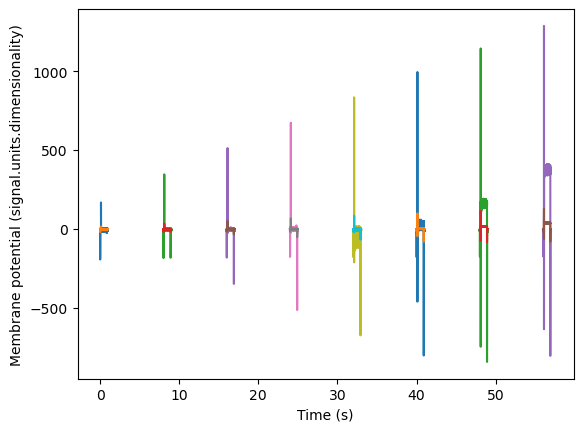

In [2]:
def plot_data(file_path):
    data = get_io(file_path).read(lazy=True)
    for segment in data[0].segments:
        signal = segment.analogsignals[0].load()
        plt.plot(signal.times, signal)
    #plt.xlim(0.0, 1) # MODIFIED REGULARLY
    #plt.ylim(-72,-60)
    plt.xlabel(f"Time ({signal.times.units.dimensionality})")
    plt.ylabel(f"Membrane potential (signal.units.dimensionality)")

plot_data('GrC_Subject15_180116/180116_0004 IV -70.abf') # plot data function modified - plt.plot(0.526, 0.53)

In [3]:
reader = get_io('GrC_Subject15_180116/180116_0004 IV -70.abf')
reader

AxonIO: GrC_Subject15_180116/180116_0004 IV -70.abf
nb_block: 1
nb_segment:  [8]
signal_streams: [Signals (chans: 2)]
signal_channels: [IN0, leak1]
spike_channels: []
event_channels: [Tag]

In [4]:
data = get_io('GrC_Subject15_180116/180116_0004 IV -70.abf').read(lazy=True)

In [5]:
# 8 pandas dataframes corresponding to 8 segments -> each segment containig 2 segments in reality 
## todo: A optomiser absolument !!!!!
df_time = pd.DataFrame(data[0].segments[0].analogsignals[0].load().times, columns=['times'])

signal_1 = np.array(data[0].segments[0].analogsignals[0].load())
df_1 = pd.DataFrame(signal_1, columns=['Segment a1','Segment b1'])

signal_2 = np.array(data[0].segments[1].analogsignals[0].load())
df_2 = pd.DataFrame(signal_2, columns=['Segment a2','Segment b2'])

signal_3 = np.array(data[0].segments[2].analogsignals[0].load())
df_3 = pd.DataFrame(signal_3, columns=['Segment a3','Segment b3'])

signal_4 = np.array(data[0].segments[3].analogsignals[0].load())
df_4 = pd.DataFrame(signal_4, columns=['Segment a4','Segment b4'])

signal_5 = np.array(data[0].segments[4].analogsignals[0].load())
df_5 = pd.DataFrame(signal_5, columns=['Segment a5','Segment b5'])

signal_6 = np.array(data[0].segments[5].analogsignals[0].load())
df_6 = pd.DataFrame(signal_6, columns=['Segment a6','Segment b6'])

signal_7 = np.array(data[0].segments[6].analogsignals[0].load())
df_7 = pd.DataFrame(signal_7, columns=['Segment a7','Segment b7'])

signal_8 = np.array(data[0].segments[7].analogsignals[0].load())
df_8 = pd.DataFrame(signal_8, columns=['Segment a8','Segment b8'])

df_merge = pd.concat([df_time,df_1,df_2,df_3,df_4,df_5,df_6,df_7,df_8], axis=1)


In [10]:
df_merge

,times,Segment a1,Segment b1,Segment a2,Segment b2,Segment a3,Segment b3,Segment a4,Segment b4,Segment a5,Segment b5,Segment a6,Segment b6,Segment a7,Segment b7,Segment a8,Segment b8
0,0.00000,-3.662109,-0.610352,-3.662109,-0.732422,-8.544922,-1.098633,-4.882812,-0.732422,-7.934570,-1.098633,-12.207030,-1.525879,-9.155273,-1.220703,-7.934570,-1.098633
1,0.00005,-4.882812,-0.793457,-10.375976,-1.342773,-7.934570,-1.159668,-7.934570,-1.037598,-9.765625,-1.342773,-3.662109,-0.549316,-2.441406,-0.549316,-6.103515,-0.976562
2,0.00010,-6.713867,-0.976562,-3.662109,-0.610352,-7.934570,-1.037598,-10.375976,-1.281738,-4.272461,-0.793457,-6.103515,-0.854492,-11.596679,-1.464844,-9.765625,-1.342773
3,0.00015,-7.324218,-0.976562,-7.934570,-1.159668,-3.051758,-0.610352,-10.986327,-1.342773,-8.544922,-1.220703,-6.713867,-0.976562,-9.155273,-1.159668,-10.375976,-1.342773
4,0.00020,0.610352,-0.244141,-6.103515,-0.854492,-4.272461,-0.671387,-6.103515,-0.915527,-7.934570,-1.220703,-10.375976,-1.342773,-7.324218,-1.037598,-6.103515,-0.976562
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,0.99975,-8.544922,-1.098633,-6.103515,-0.915527,-8.544922,-1.098633,-5.493164,-0.915527,-6.103515,-0.915527,-9.155273,-1.159668,-6.713867,-0.976562,-12.817382,-1.586914
19996,0.99980,-3.662109,-0.671387,-7.324218,-1.037598,-3.051758,-0.610352,-7.934570,-0.976562,-4.882812,-0.915527,-11.596679,-1.464844,-7.934570,-1.037598,-14.038085,-1.708984
19997,0.99985,-7.324218,-1.037598,-3.051758,-0.610352,-7.324218,-1.037598,-4.882812,-0.732422,-12.207030,-1.525879,-1.831055,-0.427246,-15.869140,-1.953125,-15.258788,-1.770020
19998,0.99990,-7.324218,-1.037598,-7.324218,-1.037598,-7.934570,-1.098633,-10.375976,-1.281738,-7.324218,-1.037598,-12.207030,-1.525879,-12.207030,-1.586914,-8.544922,-1.159668


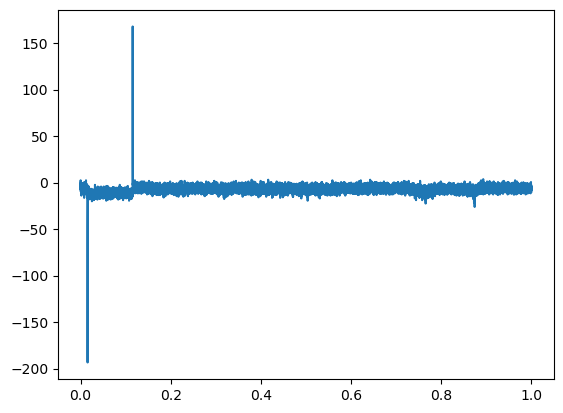

In [6]:
plt.plot(df_merge['times'], df_merge['Segment a1'])


Segment a1


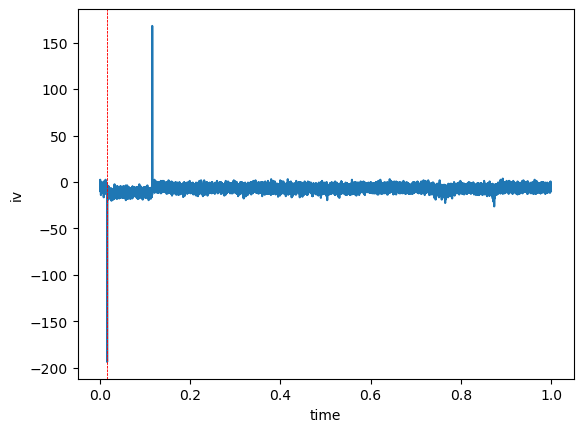

Segment b1


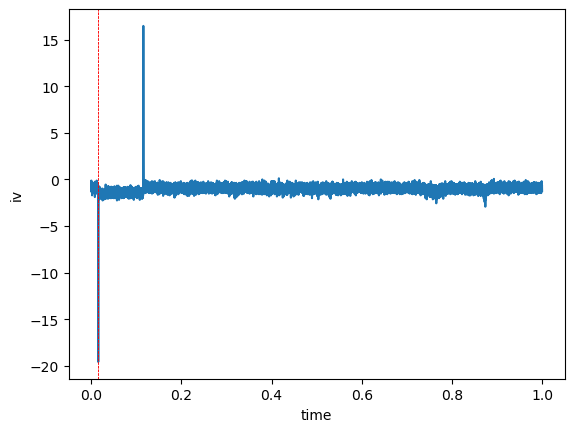

Segment a2


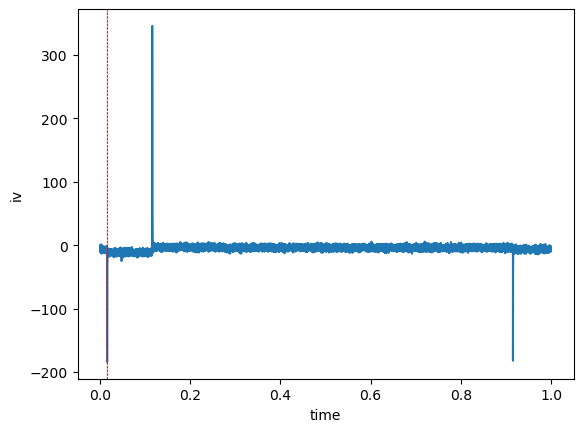

Segment b2


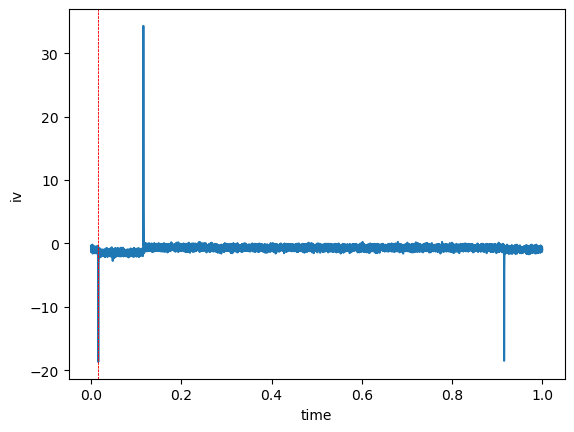

Segment a3


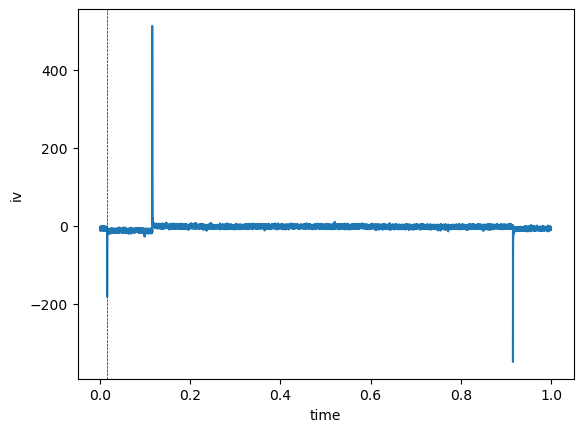

Segment b3


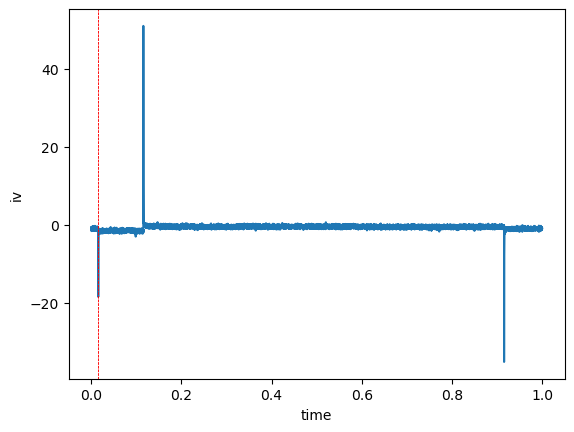

Segment a4


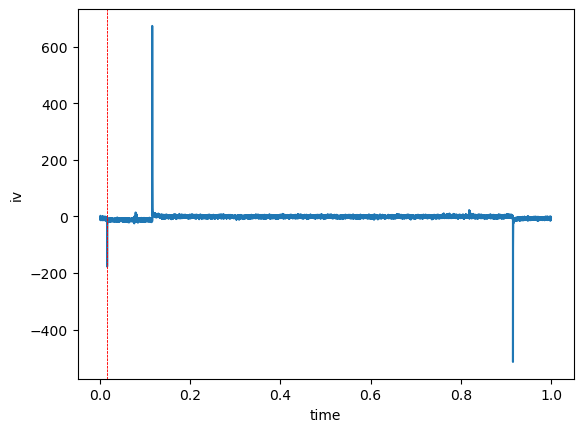

Segment b4


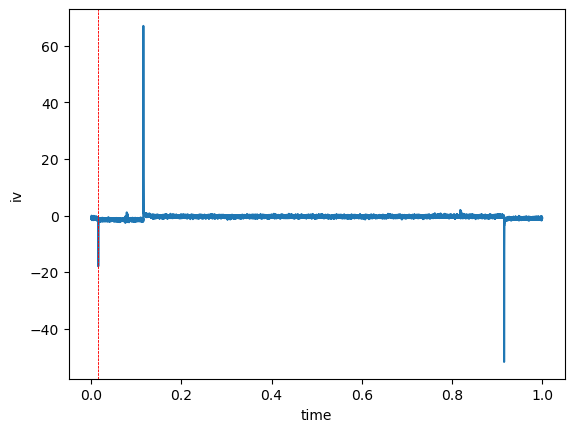

Segment a5


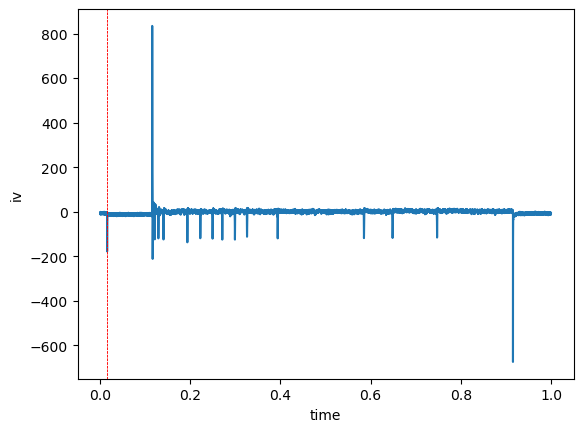

Segment b5


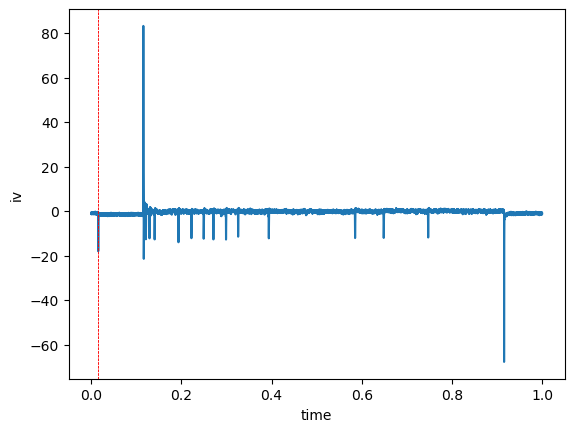

Segment a6


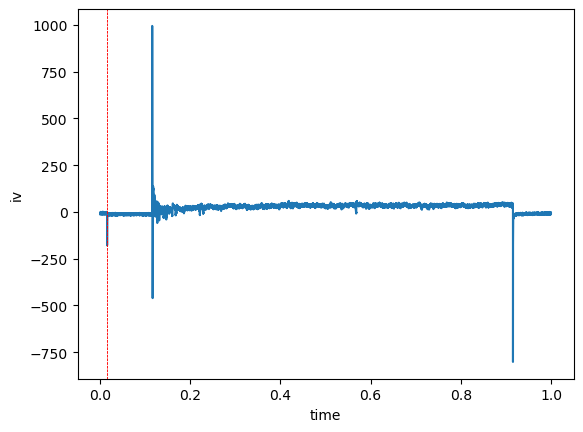

Segment b6


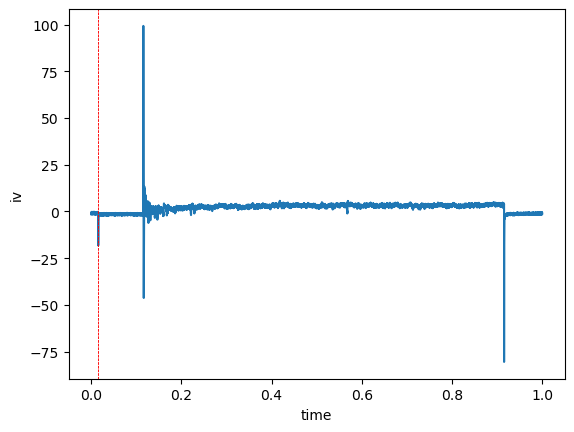

Segment a7


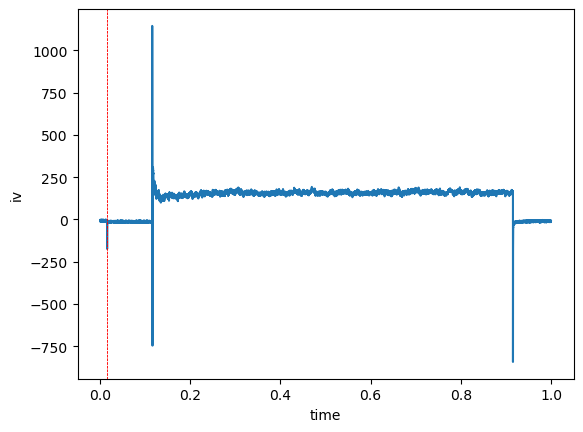

Segment b7


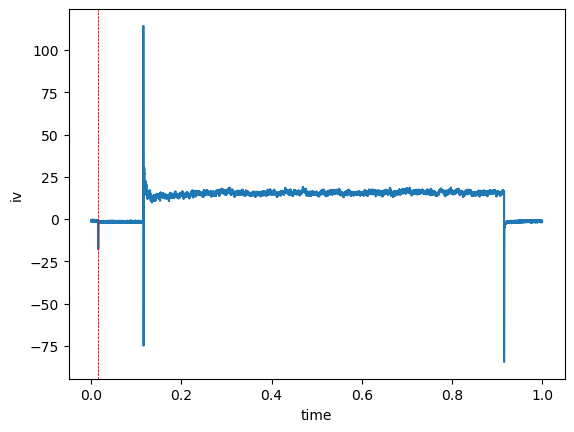

Segment a8


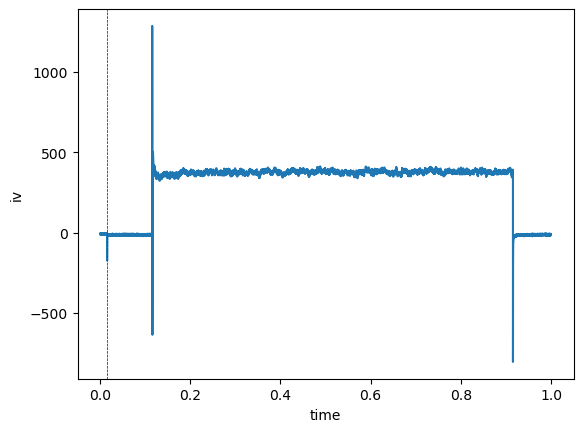

Segment b8


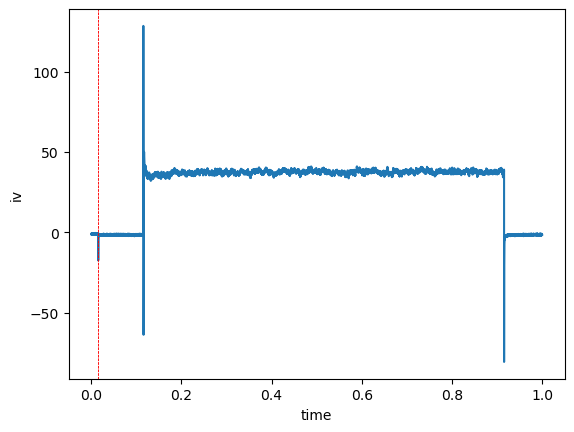

In [44]:
for column in df_merge.columns[1:]:
    plt.plot(df_merge['times'], df_merge[column])   
    #plt.title(f'Plot of {column}')
    plt.xlabel('time')
    plt.ylabel('iv')
    #plt.xlim(0.0145, 0.0165)
    plt.axvline(0.0150, color='r', ls='--', lw=0.5)
    plt.axvline(0.0155, color='r', ls='--', lw=0.5)
    print(column)
    plt.show()


In [88]:
df_merge.columns[1:]

Index(['Segment a1', 'Segment b1', 'Segment a2', 'Segment b2', 'Segment a3',
       'Segment b3', 'Segment a4', 'Segment b4', 'Segment a5', 'Segment b5',
       'Segment a6', 'Segment b6', 'Segment a7', 'Segment b7', 'Segment a8',
       'Segment b8'],
      dtype='object')

In [43]:
for column in df_merge.columns[1:]:
    signal = df_merge[column]
    signalv = np.array(signal)
    #print(signalv)
    mean = sum(signalv[:100])/len(signalv[:100])
    threshold_up = mean + 3
    threshold_down = mean - 3
    baseline_voltage = df_merge[column].iloc[:df_merge[column].__len__()].mean()  # Moyenne du voltage au repos
    stimulation_onset = df_merge[df_merge[column] > baseline_voltage + threshold_up].index[0]
stimulation_onset

2313

In [38]:
baseline_voltage = df_merge[column].iloc[:df_merge[column].__len__()].mean()  # Moyenne du voltage au repos
baseline_voltagemean

29.503159

Onset de la stimulation: 0.11565 secondes
Fin de la stimulation: 0.9153 secondes
Durée de la stimulation: 0.79965 secondes


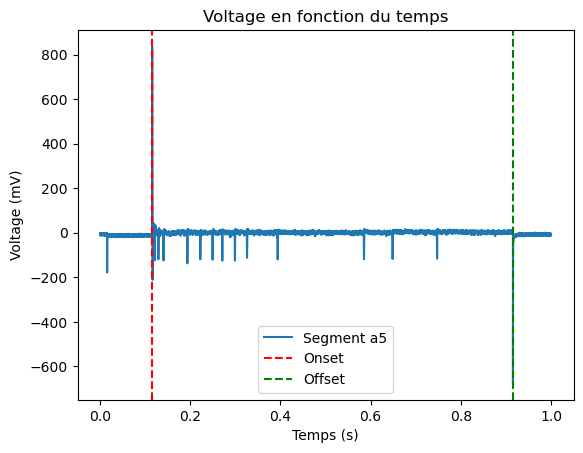

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Exemple de génération de données
#data = {'time': , 'voltage': np.random.normal(0, 1, 1000)}
#df = pd.DataFrame(data)
# Ajout d'une stimulation artificielle
#df.loc[300:700, 'voltage'] += 50  # Stimulation entre les indices 300 et 700
#df['time'] = np.arange(len(df)) * 0.1  # Exemple de colonne de temps en secondes

# Afficher les premières lignes du dataframe
#print(df.head())

# Détection de l'onset de la stimulation
threshold = 10  # Seuil pour détecter un changement significatif
baseline_voltage = df_merge['Segment a5'].iloc[:100].mean()  # Moyenne du voltage au repos
stimulation_onset = df_merge[df_merge['Segment a5'] > baseline_voltage + threshold].index[0]

# Détection de la fin de la stimulation
stimulation_offset = df_merge[df_merge['Segment a5'] > baseline_voltage + threshold].index[-1]

# Calcul de la durée de la stimulation
stimulation_duration = df_merge['times'].iloc[stimulation_offset] - df_merge['times'].iloc[stimulation_onset]

print(f"Onset de la stimulation: {df_merge['times'].iloc[stimulation_onset]} secondes")
print(f"Fin de la stimulation: {df_merge['times'].iloc[stimulation_offset]} secondes")
print(f"Durée de la stimulation: {stimulation_duration} secondes")

# Visualisation de la stimulation
plt.plot(df_merge['times'], df_merge['Segment a5'], label='Segment a5')
plt.axvline(x=df_merge['times'].iloc[stimulation_onset], color='r', linestyle='--', label='Onset')
plt.axvline(x=df_merge['times'].iloc[stimulation_offset], color='g', linestyle='--', label='Offset')
plt.title('Voltage en fonction du temps')
plt.xlabel('Temps (s)')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.show()

Onset de la stimulation: 0.11565 secondes
Fin de la stimulation: 0.116 secondes
Durée de la stimulation: 0.0003500000000000031 secondes


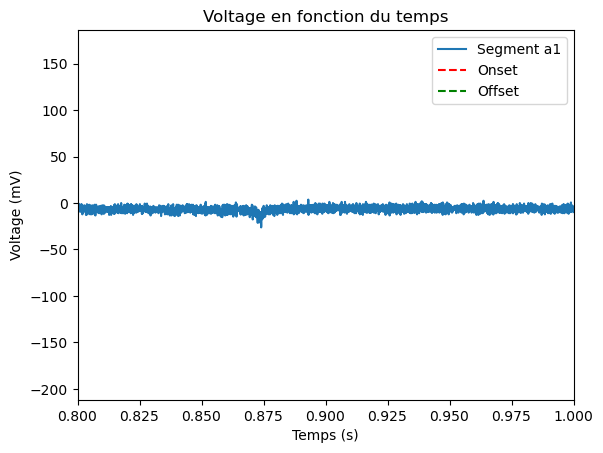

Onset de la stimulation: 0.11565 secondes
Fin de la stimulation: 0.11565 secondes
Durée de la stimulation: 0.0 secondes


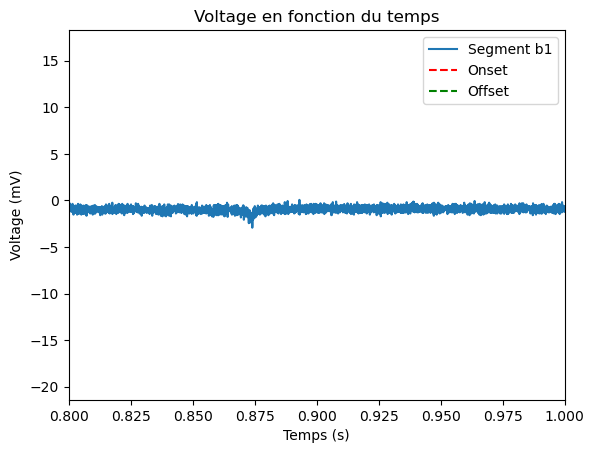

Onset de la stimulation: 0.11565 secondes
Fin de la stimulation: 0.11625 secondes
Durée de la stimulation: 0.0006000000000000033 secondes


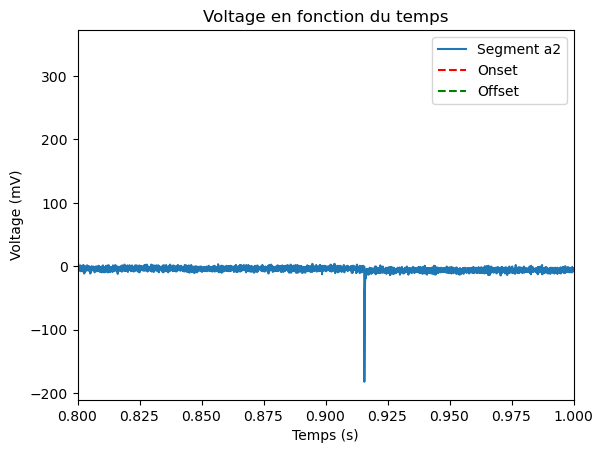

Onset de la stimulation: 0.11565 secondes
Fin de la stimulation: 0.11575 secondes
Durée de la stimulation: 0.00010000000000000286 secondes


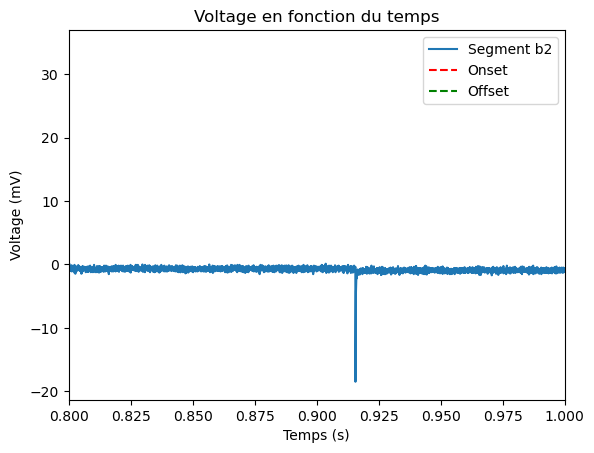

Onset de la stimulation: 0.11565 secondes
Fin de la stimulation: 0.52035 secondes
Durée de la stimulation: 0.40469999999999995 secondes


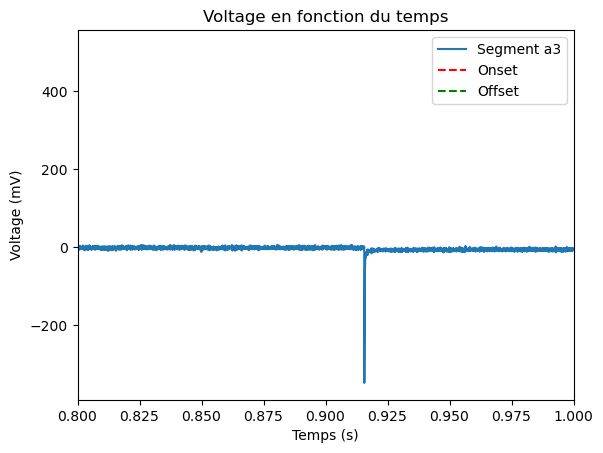

Onset de la stimulation: 0.11565 secondes
Fin de la stimulation: 0.1158 secondes
Durée de la stimulation: 0.00014999999999999736 secondes


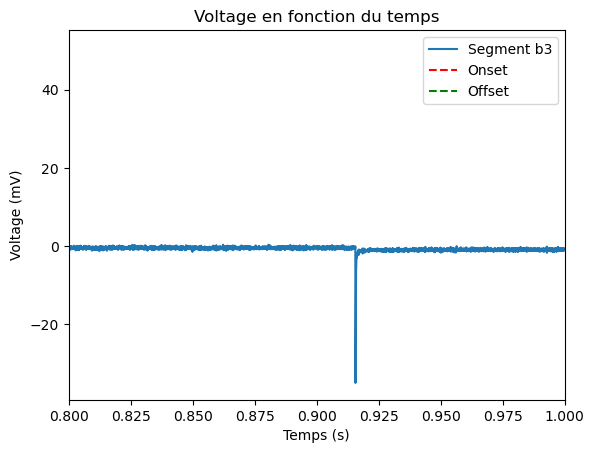

Onset de la stimulation: 0.0789 secondes
Fin de la stimulation: 0.82745 secondes
Durée de la stimulation: 0.74855 secondes


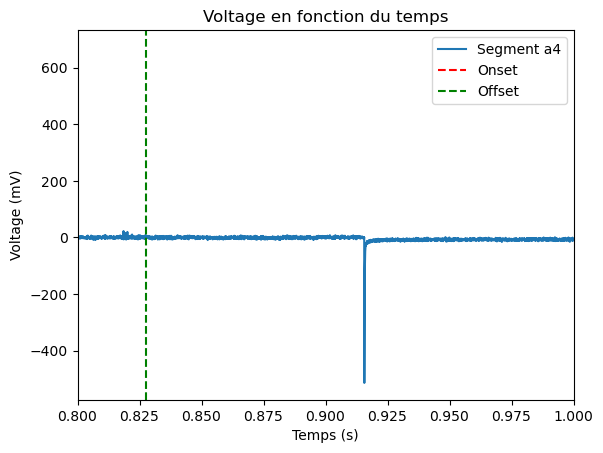

Onset de la stimulation: 0.11565 secondes
Fin de la stimulation: 0.1158 secondes
Durée de la stimulation: 0.00014999999999999736 secondes


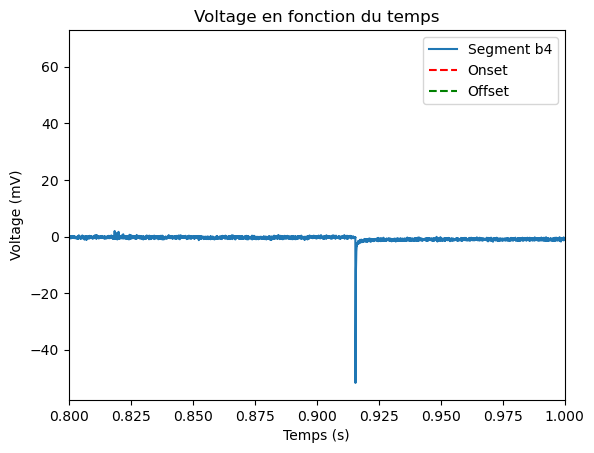

Onset de la stimulation: 0.11565 secondes
Fin de la stimulation: 0.91435 secondes
Durée de la stimulation: 0.7987 secondes


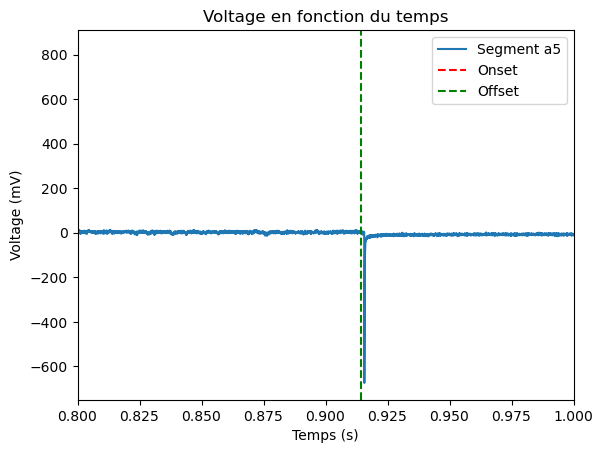

Onset de la stimulation: 0.11565 secondes
Fin de la stimulation: 0.11585 secondes
Durée de la stimulation: 0.00019999999999999185 secondes


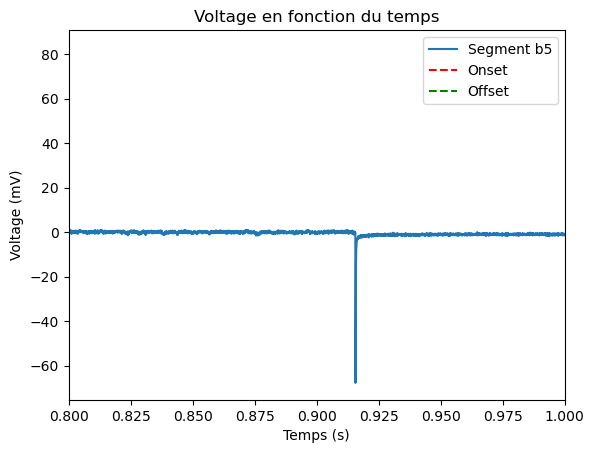

Onset de la stimulation: 0.11565 secondes
Fin de la stimulation: 0.9156 secondes
Durée de la stimulation: 0.7999499999999999 secondes


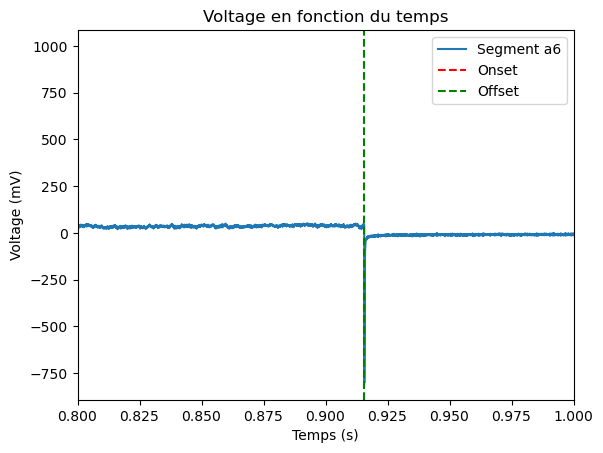

Onset de la stimulation: 0.11565 secondes
Fin de la stimulation: 0.1159 secondes
Durée de la stimulation: 0.0002500000000000002 secondes


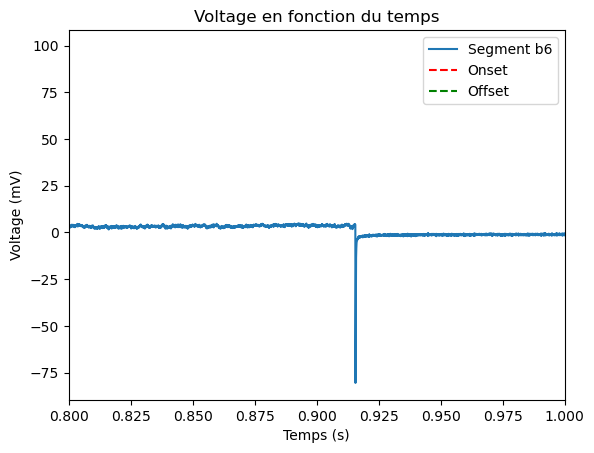

Onset de la stimulation: 0.11565 secondes
Fin de la stimulation: 0.9156 secondes
Durée de la stimulation: 0.7999499999999999 secondes


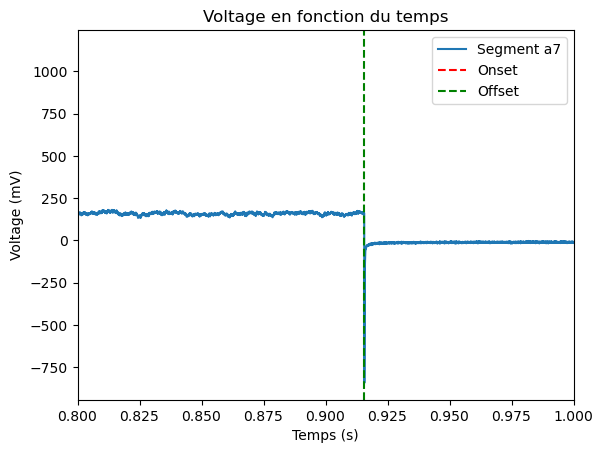

Onset de la stimulation: 0.11565 secondes
Fin de la stimulation: 0.9156 secondes
Durée de la stimulation: 0.7999499999999999 secondes


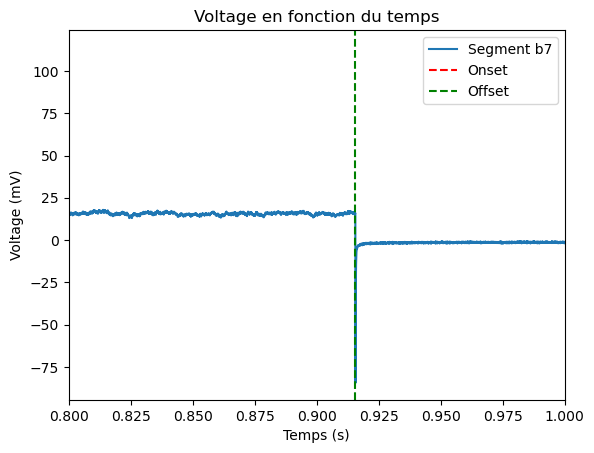

Onset de la stimulation: 0.11565 secondes
Fin de la stimulation: 0.9156 secondes
Durée de la stimulation: 0.7999499999999999 secondes


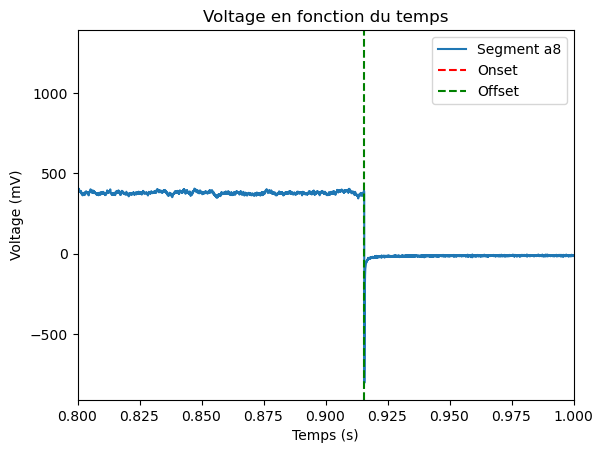

Onset de la stimulation: 0.11565 secondes
Fin de la stimulation: 0.9156 secondes
Durée de la stimulation: 0.7999499999999999 secondes


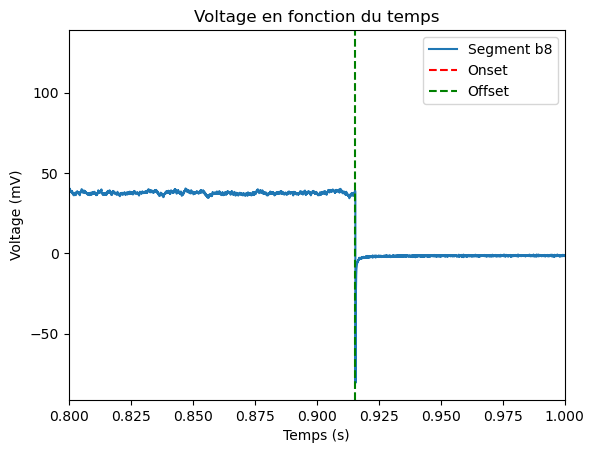

In [57]:
for column in df_merge.columns[1:]:
    threshold = 15  # Seuil pour détecter un changement significatif
    baseline_voltage = df_merge[column].iloc[:100].mean()  # Moyenne du voltage au repos
    stimulation_onset = df_merge[df_merge[column] > baseline_voltage + threshold].index[0]

    # Détection de la fin de la stimulation
    stimulation_offset = df_merge[df_merge[column] > baseline_voltage + threshold].index[-1]

    # Calcul de la durée de la stimulation
    stimulation_duration = df_merge['times'].iloc[stimulation_offset] - df_merge['times'].iloc[stimulation_onset]

    print(f"Onset de la stimulation: {df_merge['times'].iloc[stimulation_onset]} secondes")
    print(f"Fin de la stimulation: {df_merge['times'].iloc[stimulation_offset]} secondes")
    print(f"Durée de la stimulation: {stimulation_duration} secondes")

    # Visualisation de la stimulation
    plt.plot(df_merge['times'], df_merge[column], label=column)
    plt.axvline(x=df_merge['times'].iloc[stimulation_onset], color='r', linestyle='--', label='Onset')
    plt.axvline(x=df_merge['times'].iloc[stimulation_offset], color='g', linestyle='--', label='Offset')
    plt.title('Voltage en fonction du temps')
    plt.xlabel('Temps (s)')
    plt.ylabel('Voltage (mV)')
    plt.xlim(0.8,1)
    plt.legend()
    plt.show()